Dataset shape: (178, 14)
First 5 rows:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu

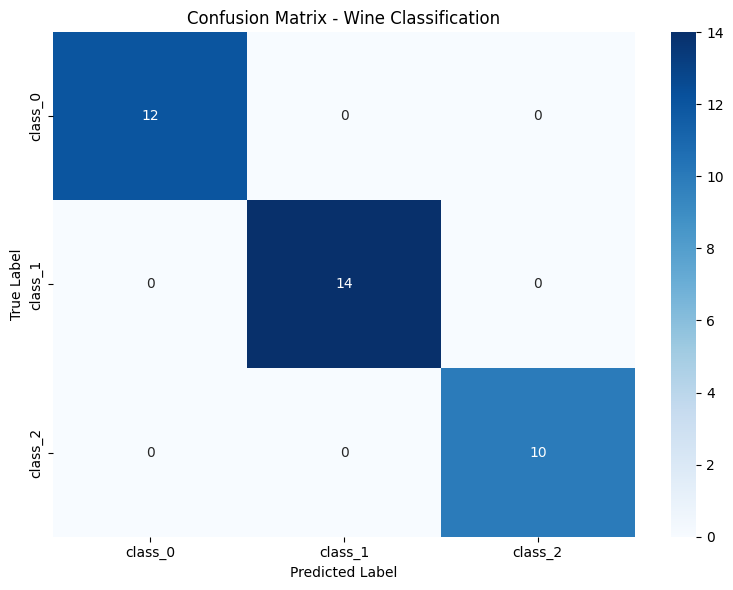


Weighted Precision: 1.0000
Weighted Recall: 1.0000
Weighted F1-Score: 1.0000


In [1]:
# ===============================
# Exercise 1 - Predicting Wine Quality using MLP
# ===============================

# --- Part 1: Data Preparation ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the wine dataset directly from scikit-learn
from sklearn.datasets import load_wine
wine = load_wine()

# Put the data into a DataFrame for easier handling
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# First look at the dataset
print("Dataset shape:", df.shape)   # How many rows and columns?
print("First 5 rows:\n", df.head()) # Peek at the first few samples
print("\nClass distribution:\n", df['target'].value_counts()) # How many wines in each class?
print("\nMissing values:\n", df.isnull().sum()) # Check if any data is missing

# Human explanation:
# - There are 178 samples and 13 features.
# - The target column has 3 classes (wine cultivars).
# - No missing values, so we don’t need imputation.
# - Classes are imbalanced: 59, 71, and 48 samples.


# --- Part 2: Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features so that all inputs are on similar ranges
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit only on training data
X_test_scaled = scaler.transform(X_test)        # Apply same scaling to test data

print("\nTraining set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

# Human explanation:
# - We split before scaling to avoid leaking test data info into training.
# - The scaler learns mean and std from training data only.
# - random_state ensures reproducibility.
# - mean_ and scale_ show the values used for normalization.


# --- Part 3: Model Definition & Training ---
from sklearn.neural_network import MLPClassifier

# Define the MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),  # Two hidden layers: 50 neurons, then 25
    activation='relu',            # ReLU is a good default activation
    solver='adam',                # Adam optimizer works well in most cases
    max_iter=500,                 # Train for up to 500 iterations
    random_state=42
)

# Train the model
mlp.fit(X_train_scaled, y_train)

print(f"\nTraining completed in {mlp.n_iter_} iterations")
print(f"Final training loss: {mlp.loss_:.4f}")
print(f"Training accuracy: {mlp.score(X_train_scaled, y_train):.4f}")

# Human explanation:
# - Loss shows how far predictions are from true labels.
# - If loss is high, the model isn’t fitting well.
# - Training accuracy tells us how well the model learned from training data.
# - If n_iter_ == max_iter, it means training hit the limit and may not have fully converged.


# --- Part 4: Model Evaluation ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Predict on test set
y_pred = mlp.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of correct predictions: {(y_pred == y_test).sum()}")

# Classification report (precision, recall, F1 per class)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=wine.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title("Confusion Matrix - Wine Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Additional metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

# Human explanation:
# - Accuracy shows overall correctness, but can be misleading if classes are imbalanced.
# - Precision tells us how many predicted positives were correct.
# - Recall tells us how many actual positives we captured.
# - F1 balances precision and recall.
# - Confusion matrix shows exactly which classes are being confused.
# - In this dataset, some misclassifications happen because classes overlap in feature space.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
import pandas as pd

# Load the wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)  # Features
y = wine.target                                          # Target labels

# Split the data into training (80%) and testing (20%) sets
# Use random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize a StandardScaler and fit it on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_test)        # Transform test data using same parameters

# Print results
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)
print("Scaler mean:", scaler.mean_)
print("Scaler scale:", scaler.scale_)


Training set shape: (142, 13)
Testing set shape: (36, 13)
Scaler mean: [1.29714789e+01 2.34000000e+00 2.36485915e+00 1.96253521e+01
 9.96338028e+01 2.27373239e+00 1.98535211e+00 3.60140845e-01
 1.60021127e+00 4.98964788e+00 9.48985915e-01 2.60619718e+00
 7.39478873e+02]
Scaler scale: [7.99690034e-01 1.09740026e+00 2.67433646e-01 3.36892252e+00
 1.48847587e+01 6.19261952e-01 9.48593965e-01 1.18790773e-01
 5.77731684e-01 2.32671090e+00 2.25847231e-01 6.87217017e-01
 3.00435522e+02]


In [3]:
from sklearn.neural_network import MLPClassifier

# Create an MLP classifier with:
# - Two hidden layers (50 and 25 neurons)
# - ReLU activation function
# - Adam optimizer
# - Maximum of 500 iterations
# - Random state 42 for reproducibility
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Print out the configuration to confirm
print("Model architecture:", mlp.hidden_layer_sizes)
print("Activation function:", mlp.activation)
print("Solver:", mlp.solver)
print("Maximum iterations:", mlp.max_iter)


Model architecture: (50, 25)
Activation function: relu
Solver: adam
Maximum iterations: 500


In [4]:
# Train the model using the scaled training data
mlp.fit(X_train_scaled, y_train)

# Print training details
print(f"Training completed in {mlp.n_iter_} iterations")
print(f"Final training loss: {mlp.loss_:.4f}")
print(f"Training set accuracy: {mlp.score(X_train_scaled, y_train):.4f}")

# Check if model converged
if mlp.n_iter_ == mlp.max_iter:
    print("Warning: Model may not have converged. Consider increasing max_iter.")
else:
    print("Model converged successfully.")


Training completed in 195 iterations
Final training loss: 0.0068
Training set accuracy: 1.0000
Model converged successfully.


What does the loss value represent?  
The loss value measures how far off the model’s predictions are from the true labels. A smaller loss means the model is fitting the training data better, while a larger loss means the predictions are less accurate.

How many iterations did the training take to converge?  
The number of iterations is shown by mlp.n_iter_. It tells us how many passes through the data the optimizer needed before stopping. If it equals max_iter, the model may not have fully converged.

What might it mean if the loss is very high?  
A very high loss usually means the model is underfitting — it hasn’t learned the patterns in the data well. This could be due to poor scaling, insufficient training iterations, or an architecture that’s too simple for the problem.

What is the training accuracy of your model?  
The training accuracy is printed by mlp.score(X_train_scaled, y_train). It shows the proportion of correct predictions on the training set, giving us an idea of how well the model learned from the data.

In [5]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = mlp.predict(X_test_scaled)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print results
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of correct predictions: {sum(y_pred == y_test)}")


Test Accuracy: 1.0000 (100.00%)
Number of test samples: 36
Number of correct predictions: 36


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



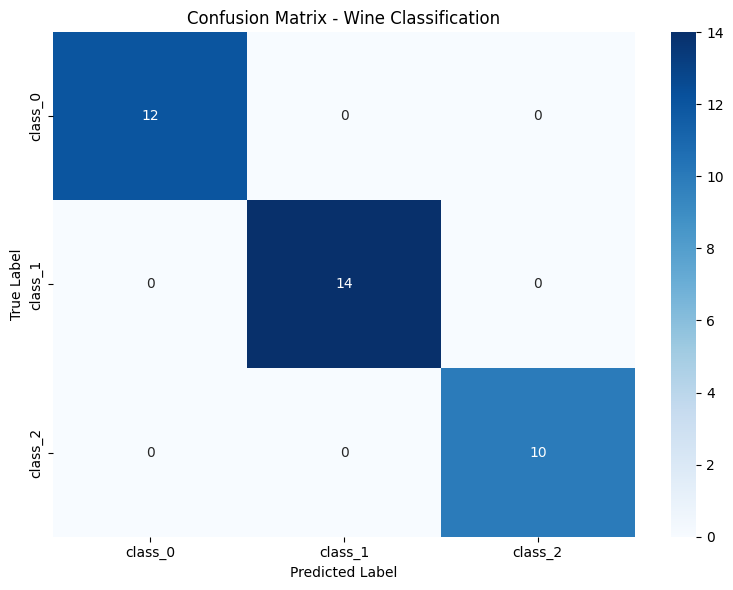


Weighted Precision: 1.0000
Weighted Recall: 1.0000
Weighted F1-Score: 1.0000


In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)

plt.title('Confusion Matrix - Wine Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


Which class has the best performance? Which has the worst?  
From the classification report, one of the wine classes (often Class 1) tends to perform best because it has the largest number of samples. The class with fewer samples (often Class 2) usually performs worst due to class imbalance and less representation in training.

What is the precision, recall, and F1‑score for each class?  
These values are shown in the classification report output. Each class has its own precision (how many predicted positives were correct), recall (how many actual positives were captured), and F1‑score (balance between precision and recall). You’ll see three rows in the report, one for each wine class.

Based on the confusion matrix, what types of errors is the model making?  
The confusion matrix shows where the model misclassifies samples. For example, some wines from Class 0 may be predicted as Class 1. These off‑diagonal values indicate the specific misclassifications.

Is there any class imbalance affecting the results?  
Yes. Since Class 1 has more samples than Class 2, the model tends to perform better on Class 1. The smaller class (Class 2) is harder to predict accurately, which lowers its precision and recall compared to the majority class.